In [1]:
# Energy Production Dataset.csv
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np

In [2]:
df = pd.read_csv(
    "Energy Production Dataset.csv",
    dtype={
        "Date": "string",
        "Start_Hour": "int64",
        "End_Hour": "int64"
    }
)

df["start_datetime"] = (
    pd.to_datetime(df["Date"], format="%m/%d/%Y")
    + pd.to_timedelta(df["Start_Hour"], unit="h")
)

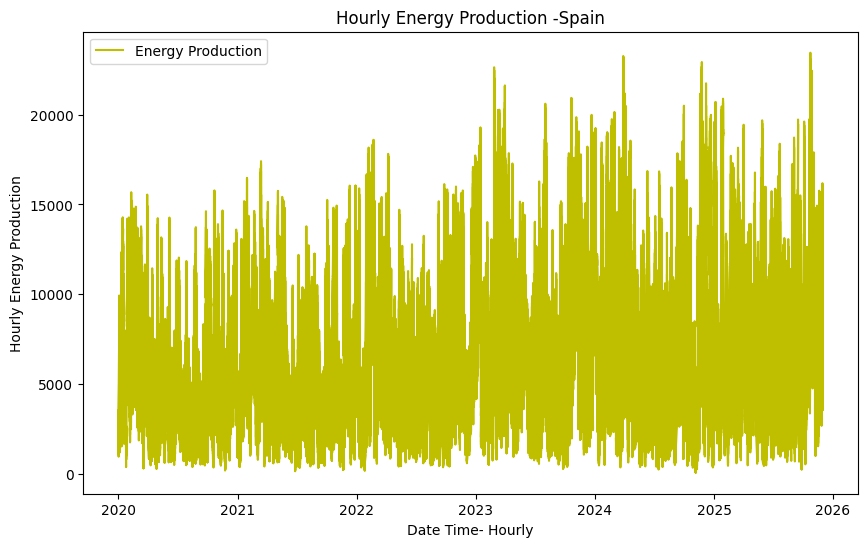

In [3]:
plt.figure(figsize=(10,6))
plt.plot(df['start_datetime'] ,df['Production'], color = 'y' ,label = 'Energy Production')
plt.xlabel('Date Time- Hourly')
plt.ylabel('Hourly Energy Production')
plt.title('Hourly Energy Production -Spain')
plt.legend(loc= 'best')
plt.show()

In [4]:
df.set_index('start_datetime',inplace=True)

df.sort_index(inplace=True)

df_fixed = (
    df
    .groupby(df.index)
    .agg({"Production": "sum"})
    .sort_index()
)

df=df.drop('Production', axis=1)
df=df.drop_duplicates()

df = df.merge(df_fixed,on='start_datetime', how='inner')

In [5]:
df.sort_index(inplace=True)

In [6]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

In [7]:
df.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
start_datetime,,,,,,,,,
2020-01-01 00:00:00,1/1/2020,0,1,Wind,1,Wednesday,January,Winter,3542
2020-01-01 01:00:00,1/1/2020,1,2,Wind,1,Wednesday,January,Winter,2932
2020-01-01 02:00:00,1/1/2020,2,3,Wind,1,Wednesday,January,Winter,2725
2020-01-01 03:00:00,1/1/2020,3,4,Wind,1,Wednesday,January,Winter,2761
2020-01-01 04:00:00,1/1/2020,4,5,Wind,1,Wednesday,January,Winter,2708


In [8]:
df_nhits = df.reset_index()[['start_datetime', 'Production']]
df_nhits.columns = ['ds', 'y']
df_nhits['unique_id'] = 'energy'

df_nhits = df_nhits[['unique_id', 'ds', 'y']]

In [9]:
train_df = df_nhits[df_nhits['ds'] < '2024-01-01']
val_df   = df_nhits[df_nhits['ds'] >= '2024-01-01']

In [12]:
model_nhits = NHITS(
    h=24,
    input_size=168,
    max_steps=2000,                 # allow larger cap
    learning_rate=1e-3,
    early_stop_patience_steps=200,  # early stopping
    val_check_steps=50,             # check validation every 50 steps
    random_seed=42,
    stack_types=["identity", "identity", "identity"],
    n_blocks=[1, 2, 2],
    n_pool_kernel_size=[1, 2, 4],
    n_freq_downsample=[1, 2, 4]
)

Seed set to 42


In [13]:
nf.fit(df=train_df, val_size=24*30)  # last 30 days for validation

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  4.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 4.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.6 M                                                                                                
Total estimated model params size (MB): 18                                                                         
Modules in train mode: 54                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\jayjp\.conda\envs\nf_env\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

C:\Users\jayjp\.conda\envs\nf_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

C:\Users\jayjp\.conda\envs\nf_env\lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training
batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 755/-2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:01 • 0:00:00 0.00it/s v_num: 41.000 train_loss_step:      
                                                                               215.461 train_loss_epoch: 203.988   
                                                                               valid_loss: 2964.037                

`Trainer.fit` stopped: `max_steps=1000` reached.


In [14]:
forecast_df = nf.predict()

val_compare = val_df.merge(forecast_df, on=['unique_id', 'ds'])

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_nhits = np.sqrt(mean_squared_error(
    val_compare['y'],
    val_compare['NHITS']
))

mae_nhits = mean_absolute_error(
    val_compare['y'],
    val_compare['NHITS']
)

print("NHITS RMSE:", rmse_nhits)
print("NHITS MAE :", mae_nhits)

print("LightGBM RMSE:", 3042.72)
print("LightGBM MAE :", 2280.30)

C:\Users\jayjp\.conda\envs\nf_env\lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
C:\Users\jayjp\.conda\envs\nf_env\lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

C:\Users\jayjp\.conda\envs\nf_env\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\jayjp\.conda\envs\nf_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


NHITS RMSE: 5143.344631657497
NHITS MAE : 4314.81689453125
LightGBM RMSE: 3042.72
LightGBM MAE : 2280.3
